In [1]:
from jax import config
config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import torch

%load_ext autoreload
%autoreload 1

%aimport tensordev.kernel.free
%aimport tensordev.kernel.higher_order

from tensordev.kernel.free import free_kernel
from tensordev.kernel.higher_order import higher_order_kernel

# Force torch default to float64 as an extra safeguard.
torch.set_default_dtype(torch.float64)

def jax_to_torch_f64(x, *, device="cpu"):
    """
    Explicit JAX -> NumPy(float64) -> Torch(float64) bridge.
    """
    x_np = np.asarray(jax.device_get(x), dtype=np.float64).copy()
    x_torch = torch.from_numpy(x_np).to(device=device, dtype=torch.float64)
    return x_torch

def torch_to_numpy_f64(x):
    """
    Explicit Torch -> NumPy(float64) bridge.
    """
    x_np = x.detach().cpu().numpy()
    if x_np.dtype != np.float64:
        x_np = x_np.astype(np.float64, copy=False)
    return x_np

def sample_bm_paths(key, *, n_pairs, n_steps, dim, horizon=1.0):
    dt = horizon / n_steps
    kx, ky = jr.split(key)

    dX = jnp.sqrt(dt) * jr.normal(kx, (n_pairs, n_steps, dim), dtype=jnp.float64)
    dY = jnp.sqrt(dt) * jr.normal(ky, (n_pairs, n_steps, dim), dtype=jnp.float64)

    x0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)
    y0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)

    X = jnp.concatenate([x0, jnp.cumsum(dX, axis=1)], axis=1)
    Y = jnp.concatenate([y0, jnp.cumsum(dY, axis=1)], axis=1)

    # Hard dtype checks
    assert X.dtype == jnp.float64
    assert Y.dtype == jnp.float64

    return X, Y

In [2]:
SEED = 2404029296
DIM = 2
N_FINE = 2 ** 12
DEGREES = [1, 2, 3, 4]
K_VALUES = list(range(4 + 2, 12))
N_PAIRS = 100
HORIZON = 1.0
naive_ref = True

key = jr.PRNGKey(SEED)
X_paths, Y_paths = sample_bm_paths(
    key,
    n_pairs=N_PAIRS,
    n_steps=N_FINE,
    dim=DIM,
    horizon=HORIZON,
)

dX = (jnp.diff(X_paths, axis=1),)
dY = (jnp.diff(Y_paths, axis=1),)

fine_vals = np.asarray(
    free_kernel(
        dX,
        dY,
        evaluate="terminal",
        return_fg=False,
        pairwise=False,
        backend="scan",
        dyadic_order=0,
        increment_in=True,
    ),
    dtype=np.float64,
)

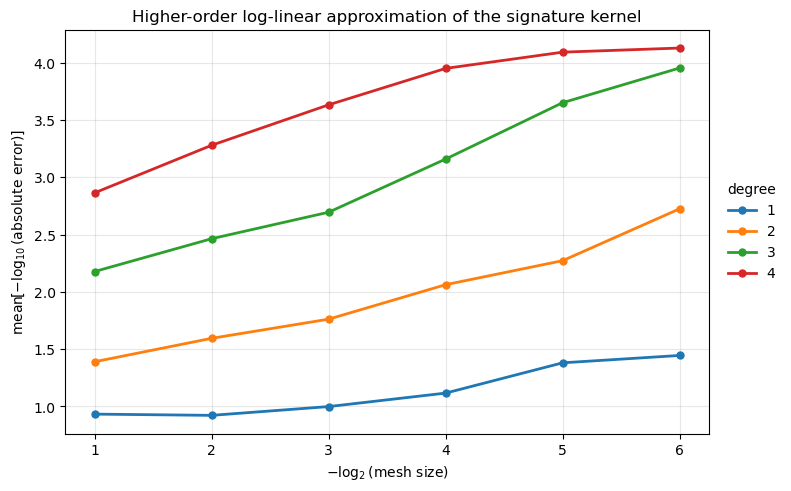

degree 1:
  -log2(mesh)=  1.0   mean_error=3.307798e-01   y=0.933251
  -log2(mesh)=  2.0   mean_error=2.531339e-01   y=0.922483
  -log2(mesh)=  3.0   mean_error=1.897716e-01   y=0.999091
  -log2(mesh)=  4.0   mean_error=1.430981e-01   y=1.116727
  -log2(mesh)=  5.0   mean_error=9.740176e-02   y=1.380907
  -log2(mesh)=  6.0   mean_error=7.652757e-02   y=1.445134

degree 2:
  -log2(mesh)=  1.0   mean_error=1.237159e-01   y=1.390180
  -log2(mesh)=  2.0   mean_error=6.610468e-02   y=1.594595
  -log2(mesh)=  3.0   mean_error=3.736588e-02   y=1.761668
  -log2(mesh)=  4.0   mean_error=1.799033e-02   y=2.062493
  -log2(mesh)=  5.0   mean_error=1.072405e-02   y=2.272156
  -log2(mesh)=  6.0   mean_error=4.029637e-03   y=2.724668

degree 3:
  -log2(mesh)=  1.0   mean_error=1.953935e-02   y=2.177384
  -log2(mesh)=  2.0   mean_error=1.044270e-02   y=2.463630
  -log2(mesh)=  3.0   mean_error=4.328327e-03   y=2.694837
  -log2(mesh)=  4.0   mean_error=1.548103e-03   y=3.158514
  -log2(mesh)=  5.0   me

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

AGGREGATION = "mean_log"   # "log_mean" or "mean_log"
EPS = 1e-300

mean_errors = {n: [] for n in DEGREES}
all_errors = {n: [] for n in DEGREES}

# Sweep order: coarse first = faster first, and also left-to-right in the plot
K_SWEEP = K_VALUES[::-1]
x_sweep = -np.log2(np.array([(2 ** k) / N_FINE for k in K_SWEEP], dtype=float))

def aggregate_errors(errs, mode="log_mean", eps=1e-300):
    errs = np.asarray(errs, dtype=float)
    if mode == "log_mean":
        return -np.log10(np.maximum(np.mean(errs), eps))
    elif mode == "mean_log":
        return np.mean(-np.log10(np.maximum(errs, eps)))
    else:
        raise ValueError("mode must be 'log_mean' or 'mean_log'")

def ylabel_for(mode):
    if mode == "log_mean":
        return r"$-\log_{10}(\mathrm{mean\ absolute\ error})$"
    elif mode == "mean_log":
        return r"$\mathrm{mean}\!\left[-\log_{10}(\mathrm{absolute\ error})\right]$"
    else:
        raise ValueError("mode must be 'log_mean' or 'mean_log'")

def render_progress():
    clear_output(wait=True)
    print(f"Aggregation mode: {AGGREGATION}")

    fig, ax = plt.subplots(figsize=(7.8, 4.8), constrained_layout=True)

    for n in DEGREES:
        if not mean_errors[n]:
            continue

        xcurr = x_sweep[:len(mean_errors[n])]
        ecurr = np.array(mean_errors[n], dtype=float)

        if AGGREGATION == "log_mean":
            yplot = -np.log10(np.maximum(ecurr, EPS))
        else:
            yplot = np.array([
                np.mean(-np.log10(np.maximum(errs, EPS)))
                for errs in all_errors[n]
            ], dtype=float)

        ax.plot(
            xcurr,
            yplot,
            marker="o",
            linewidth=2,
            markersize=5,
            label=f"{n}",
        )

    ax.set_xlabel(r"$-\log_2(\mathrm{mesh\ size})$")
    ax.set_ylabel(ylabel_for(AGGREGATION))
    ax.set_title("Higher-order log-linear approximation of the signature kernel")
    ax.grid(True, alpha=0.3)

    ax.legend(
        title="degree",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=False,
    )

    display(fig)
    plt.close(fig)

    for n in DEGREES:
        if not mean_errors[n]:
            continue

        xcurr = x_sweep[:len(mean_errors[n])]
        print(f"degree {n}:")
        for i, x in enumerate(xcurr):
            e = mean_errors[n][i]
            y = aggregate_errors(all_errors[n][i], mode=AGGREGATION, eps=EPS)
            print(f"  -log2(mesh)={x:5.1f}   mean_error={e:.6e}   y={y:.6f}")
        print()

render_progress()

for n in DEGREES:
    for k in K_SWEEP:
        block_size = 2 ** k

        approx_vals = np.asarray(
            higher_order_kernel(
                dX,
                dY,
                log_steps=(block_size, block_size),
                log_degree=(n, n),
                evaluate="terminal",
                return_fg=False,
                pairwise=False,
                backend="scan",
                dyadic_order=6,
                increment_input=True,
            )
        )

        errs = np.abs(approx_vals - fine_vals)
        all_errors[n].append(errs)
        mean_errors[n].append(float(np.mean(errs)))

        render_progress()

# Final arrays in plotted order
xplot = x_sweep

In [ ]:
# Reproduce the degree-1 line using a local higher-order repo folder.
# Adjust REPO_ROOT to your local path.

from jax import config
config.update("jax_enable_x64", True)

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

# ------------------------------------------------------------
# set your local repo path here
# ------------------------------------------------------------
REPO_ROOT = Path("/high-order-sigkernel")   # <- change this

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    import roughpy  # noqa: F401
except Exception as e:
    raise ImportError(
        "This cell needs `roughpy` installed, because the higher-order package depends on it."
    ) from e

from src.roughsigkernel import RoughSigKer

# ------------------------------------------------------------
# parameters
# ------------------------------------------------------------
SEED = 2404029296
DIM = 2
N_FINE = 2**12
K_VALUES = list(range(4, 12))   # k=4,...,11
N_PAIRS = 100
HORIZON = 1.0
DEGREE = 1
SOLVER = "goursat"
REFINE = 1

# ------------------------------------------------------------
# Brownian paths
# ------------------------------------------------------------
def sample_bm_paths(key, *, n_pairs, n_steps, dim, horizon=1.0):
    dt = horizon / n_steps
    kx, ky = jr.split(key)

    dX = jnp.sqrt(dt) * jr.normal(kx, (n_pairs, n_steps, dim), dtype=jnp.float64)
    dY = jnp.sqrt(dt) * jr.normal(ky, (n_pairs, n_steps, dim), dtype=jnp.float64)

    x0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)
    y0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)

    X = jnp.concatenate([x0, jnp.cumsum(dX, axis=1)], axis=1)
    Y = jnp.concatenate([y0, jnp.cumsum(dY, axis=1)], axis=1)
    return X, Y

key = jr.PRNGKey(SEED)
X_jax, Y_jax = sample_bm_paths(
    key,
    n_pairs=N_PAIRS,
    n_steps=N_FINE,
    dim=DIM,
    horizon=HORIZON,
)

X = np.asarray(jax.device_get(X_jax), dtype=np.float64)
Y = np.asarray(jax.device_get(Y_jax), dtype=np.float64)

assert X.shape == (N_PAIRS, N_FINE + 1, DIM)
assert Y.shape == (N_PAIRS, N_FINE + 1, DIM)
assert X.dtype == np.float64
assert Y.dtype == np.float64

# ------------------------------------------------------------
# fine reference
# ------------------------------------------------------------
fine_solver = RoughSigKer(S=1, T=1, degree=DEGREE, solver=SOLVER)

fine_vals = np.empty(N_PAIRS, dtype=np.float64)
for a in range(N_PAIRS):
    fine_vals[a] = fine_solver.kerPDE(
        X[a],
        Y[a],
        times=N_FINE,
        refine=REFINE,
    )

# ------------------------------------------------------------
# coarse errors
# ------------------------------------------------------------
x_axis = []
errs = []

for k in K_VALUES:
    step = 2**k
    coarse_solver = RoughSigKer(S=step, T=step, degree=DEGREE, solver=SOLVER)

    coarse_vals = np.empty(N_PAIRS, dtype=np.float64)
    terminal_time = N_FINE // step

    for a in range(N_PAIRS):
        coarse_vals[a] = coarse_solver.kerPDE(
            X[a],
            Y[a],
            times=terminal_time,
            refine=REFINE,
        )

    err = np.mean(np.abs(coarse_vals - fine_vals))
    errs.append(err)

    mesh_size = step / N_FINE
    x_axis.append(-np.log2(mesh_size))

errs = np.asarray(errs, dtype=np.float64)
y_axis = -np.log10(errs)

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
plt.figure(figsize=(6.4, 4.2))
plt.plot(x_axis, y_axis, marker="o")
plt.xlabel(r"$-\log_2(\mathrm{mesh\ size})$")
plt.ylabel(r"$-\log_{10}(\mathrm{mean\ absolute\ error})$")
plt.title("Degree-1 line via higher-order package only")
plt.grid(True, alpha=0.3)
plt.show()

print("\n(-log2(mesh size), -log10(mean abs error)):")
for x, y in zip(x_axis, y_axis):
    print(f"{x:4.1f}   {y:.12f}")

In [ ]:
# Salvi-only degree-1 line (self-consistent naive reference, all in float64)

from jax import config
config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import torch

from sigkernel import SigKernel, LinearKernel

# -----------------------------
# parameters
# -----------------------------
SEED = 2404029296
DIM = 2
N_FINE = 2**12
K_VALUES = list(range(4, 12))   # paper-style range: block sizes 2^k, k=4,...,11
N_PAIRS = 100
HORIZON = 1.0
MAX_BATCH = 5                  # reduce if memory gets tight

# -----------------------------
# hard float64 safeguards
# -----------------------------
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def jax_to_torch_f64(x, *, device=DEVICE):
    x_np = np.asarray(jax.device_get(x), dtype=np.float64).copy()
    x_torch = torch.from_numpy(x_np).to(device=device, dtype=torch.float64)
    assert x_torch.dtype == torch.float64
    return x_torch

def torch_to_numpy_f64(x):
    x_np = x.detach().cpu().numpy()
    if x_np.dtype != np.float64:
        x_np = x_np.astype(np.float64, copy=False)
    return x_np

# -----------------------------
# Brownian paths
# -----------------------------
def sample_bm_paths(key, *, n_pairs, n_steps, dim, horizon=1.0):
    dt = horizon / n_steps
    kx, ky = jr.split(key)

    dX = jnp.sqrt(dt) * jr.normal(kx, (n_pairs, n_steps, dim), dtype=jnp.float64)
    dY = jnp.sqrt(dt) * jr.normal(ky, (n_pairs, n_steps, dim), dtype=jnp.float64)

    x0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)
    y0 = jnp.zeros((n_pairs, 1, dim), dtype=jnp.float64)

    X = jnp.concatenate([x0, jnp.cumsum(dX, axis=1)], axis=1)
    Y = jnp.concatenate([y0, jnp.cumsum(dY, axis=1)], axis=1)

    assert X.dtype == jnp.float64
    assert Y.dtype == jnp.float64
    return X, Y

key = jr.PRNGKey(SEED)
X_paths, Y_paths = sample_bm_paths(
    key,
    n_pairs=N_PAIRS,
    n_steps=N_FINE,
    dim=DIM,
    horizon=HORIZON,
)

print("JAX X dtype:", X_paths.dtype)
print("JAX Y dtype:", Y_paths.dtype)

# -----------------------------
# Salvi naive solver = degree-1 analogue
# -----------------------------
salvi = SigKernel(
    LinearKernel(),
    dyadic_order=1,
    _naive_solver=True,
)

# fine reference with the SAME naive solver
X_fine_t = jax_to_torch_f64(X_paths)
Y_fine_t = jax_to_torch_f64(Y_paths)

print("Torch fine X dtype:", X_fine_t.dtype)
print("Torch fine Y dtype:", Y_fine_t.dtype)

fine_vals_t = salvi.compute_kernel(X_fine_t, Y_fine_t, max_batch=MAX_BATCH)
print("Torch fine output dtype:", fine_vals_t.dtype)
assert fine_vals_t.dtype == torch.float64

fine_vals = torch_to_numpy_f64(fine_vals_t)

# -----------------------------
# coarse-to-fine errors
# coarse path = keep every 2^k-th grid point
# -----------------------------

salvi = SigKernel(
    LinearKernel(),
    dyadic_order=0,
    _naive_solver=True,
)

x_axis = []
errs = []

for k in K_VALUES:
    block = 2**k

    X_coarse = X_paths[:, ::block, :]
    Y_coarse = Y_paths[:, ::block, :]

    # because block divides N_FINE, the terminal point is included automatically
    assert X_coarse.shape[1] == N_FINE // block + 1
    assert Y_coarse.shape[1] == N_FINE // block + 1
    assert X_coarse.dtype == jnp.float64
    assert Y_coarse.dtype == jnp.float64

    X_coarse_t = jax_to_torch_f64(X_coarse)
    Y_coarse_t = jax_to_torch_f64(Y_coarse)

    coarse_vals_t = salvi.compute_kernel(X_coarse_t, Y_coarse_t, max_batch=MAX_BATCH)
    assert coarse_vals_t.dtype == torch.float64

    coarse_vals = torch_to_numpy_f64(coarse_vals_t)

    err = np.mean(np.abs(coarse_vals - fine_vals))
    errs.append(err)

    mesh_size = block / N_FINE
    x_axis.append(-np.log2(mesh_size))

errs = np.asarray(errs, dtype=np.float64)
y_axis = -np.log10(errs)

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(6.4, 4.2))
plt.plot(x_axis, y_axis, marker="o")
plt.xlabel(r"$-\log_2(\mathrm{mesh\ size})$")
plt.ylabel(r"$-\log_{10}(\mathrm{mean\ absolute\ error})$")
plt.title("Degree-1 line with Salvi sigkernel (naive/self-consistent)")
plt.grid(True, alpha=0.3)
plt.show()

print("\n(-log2(mesh size), -log10(mean abs error)):")
for x, y in zip(x_axis, y_axis):
    print(f"{x:4.1f}   {y:.12f}")